# Fig S5 — Validation biology supplements (location KM, EcoTyper, module scores, GSEA)

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('validation', 'supplemental_fig5')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, write_supplementary_table, rel_path
import dlbcl.validation_figures as vf

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "DejaVu Sans"


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig5


## Fig S5 — panel overview

Panels follow manuscript order (S5A → S5B → S5C → S5D).

| Panel | Description |
|-------|-------------|
| S5A | Validation OS KM by anatomical location (5-year) |
| S5B | EcoTyper B-cell states across immune archetypes |
| S5C | Immune module scores across archetypes (validation GEP) |
| S5D | GSEA hallmark dotplot (one-vs-rest, validation) |

**Data:** `data/DLBCL_location_2026.h5ad` — validation cohort in `adata.uns['validation_cohort']`.

## Fig S5A — validation OS KM by location (5-year)

Kaplan–Meier overall survival by anatomical location in the validation cohort.

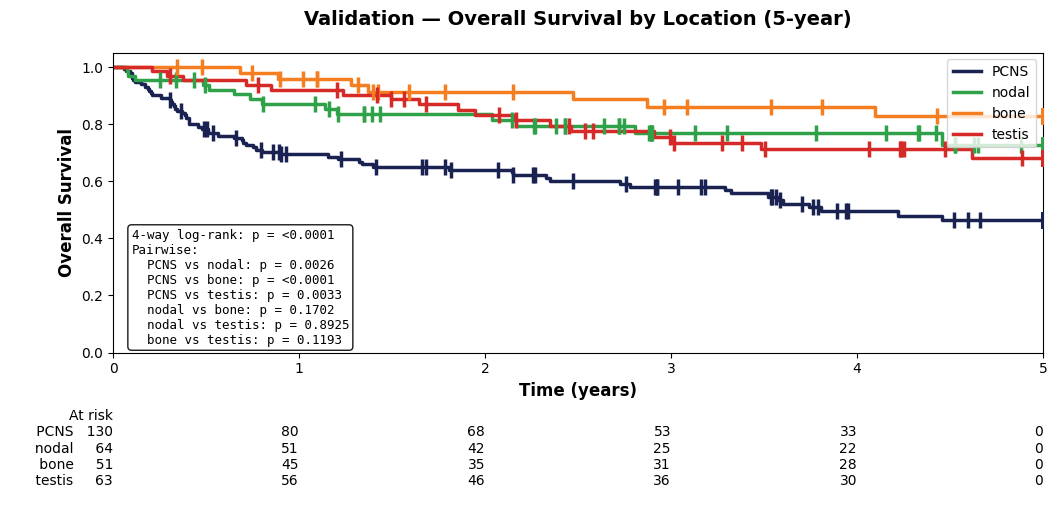

,group,n,events,global_logrank_p
0,PCNS,130,60,0.000007
1,nodal,64,14,0.000007
2,bone,51,7,0.000007
3,testis,63,17,0.000007


Wrote figures/supplemental_fig5/figS5A_val_km_os_location.svg
Saved: data/supplementary/supplemental_fig5/figS5A_val_km_os_location.csv


In [2]:
loc_os = vf.plot_km_by_location(
    surv,
    title="Validation — Overall Survival by Location (5-year)",
    ylabel="Overall Survival",
    out_path=FIG_DIR / "figS5A_val_km_os_location.svg",
)
display(loc_os)
loc_os.to_csv(OUTDIR / "figS5A_val_km_os_location_summary.csv", index=False)
log_wrote(FIG_DIR / "figS5A_val_km_os_location.svg", REPO_ROOT)
log_saved(write_supplementary_table(loc_os, REPO_ROOT, "figS5A_val_km_os_location"), REPO_ROOT)


## Fig S5B — EcoTyper B-cell states across immune archetypes

Stacked barplot of EcoTyper B-cell states (S1–S5) within predicted immune archetypes in the validation cohort.

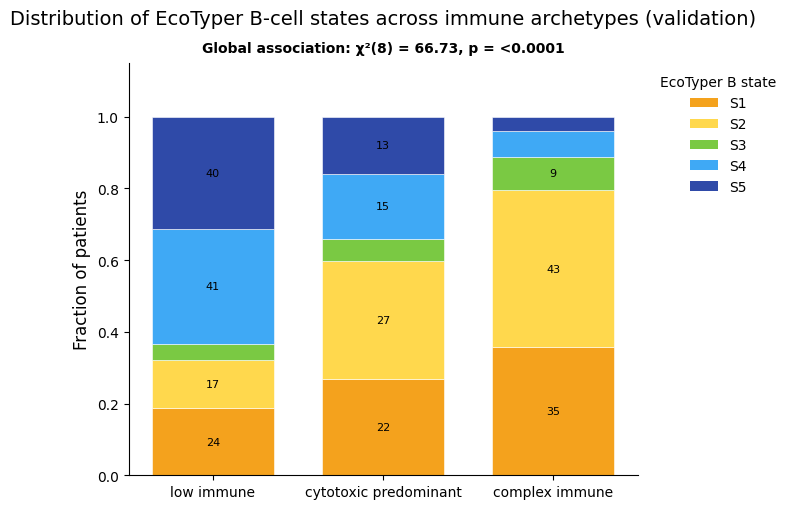

Saved: data/supplementary/supplemental_fig5/figS5B_ecotyper_counts.csv
Saved: data/supplementary/supplemental_fig5/figS5B_ecotyper_proportions.csv


,test,comparison,chi2,dof,p,p_label,min_expected_count
0,Chi-square,immune archetype x EcoTyper B-cell state,66.728693,8,2.194545e-11,<0.0001,5.324675


In [3]:
from dlbcl.validation_classifications import (
    load_case_classification_validation,
    load_ecotyper_b_state_validation,
)

vc = adata.uns["validation_cohort"]
case_cc = load_case_classification_validation(vc, pred)
bstate = load_ecotyper_b_state_validation(vc)

BCELL_OUT = FIG_DIR / "bcell_state_ecotyper"
counts_3m, props_3m, stats_3m = vf.plot_ecotyper_bcell_by_archetype(
    bstate,
    case_cc["tumorimmune_archetype"].reindex(bstate.index),
    out_dir=BCELL_OUT,
    out_stem="ecotyper_b_state_by_archetype",
)
log_saved(write_supplementary_table(counts_3m.reset_index(names="archetype"), REPO_ROOT, "figS5B_ecotyper_counts"), REPO_ROOT)
log_saved(write_supplementary_table(props_3m.reset_index(names="archetype"), REPO_ROOT, "figS5B_ecotyper_proportions"), REPO_ROOT)
display(stats_3m)

## Validation GEP — archetype DE prep

Computes validation archetype differential expression inputs (`X`, `y`, `cluster_order`) used by **Fig S5C** and **Fig S5D**.

Genes tested: 797 | patients: 308
pred_abundance_cluster_30_label
low immune               128
cytotoxic predominant     82
complex immune            98
Name: count, dtype: int64
Global q<0.05: 623


,target_class,driver_direction,n
0,complex immune,DOWN,65
1,complex immune,UP,115
2,cytotoxic predominant,DOWN,13
3,cytotoxic predominant,UP,50
4,low immune,DOWN,246
5,low immune,UP,86


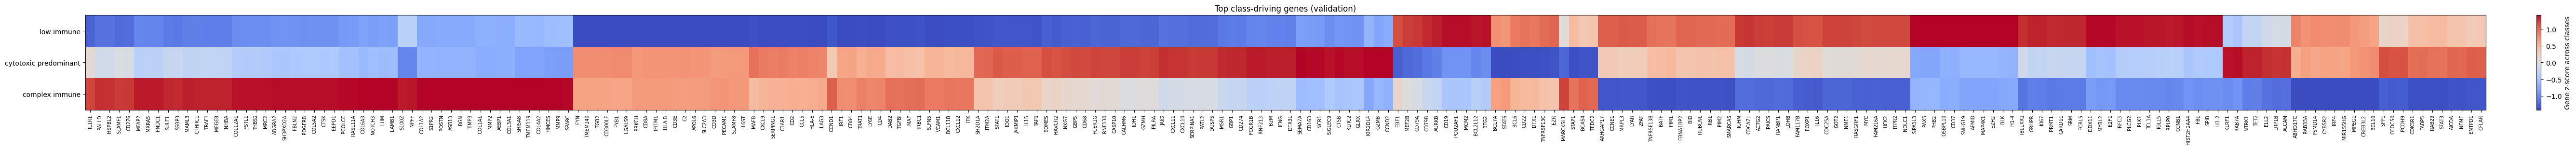

Wrote figures/supplemental_fig5/figS5_supp_val_top_class_drivers_heatmap.svg
Saved: data/supplementary/supplemental_fig5/figS5_supp_val_top_class_drivers_heatmap_zscores.csv


In [4]:
X, y, cluster_order, global_de, pairwise, class_drivers = vf.compute_archetype_de(gep, archetype_label)
print("Genes tested:", X.shape[1], "| patients:", X.shape[0])
print(y.value_counts().reindex(cluster_order))
print("Global q<0.05:", int((global_de["q"] < 0.05).sum()))

GEP_OUT = FIG_DIR / "de_gene_expression"
GEP_OUT.mkdir(parents=True, exist_ok=True)
global_de.to_csv(GEP_OUT / "global_3class_anova_gene_expression.csv", index=False)
class_drivers.to_csv(GEP_OUT / "class_driving_UP_DOWN_genes.csv", index=False)

n_drivers = (
    class_drivers[class_drivers["driver_direction"] != "not_driver"]
    .groupby(["target_class", "driver_direction"]).size().reset_index(name="n")
)
display(n_drivers)

_, zmat = vf.plot_top_driver_heatmap(
    X, y, cluster_order, class_drivers,
    out_path=FIG_DIR / "figS5_supp_val_top_class_drivers_heatmap.svg",
)
log_wrote(FIG_DIR / "figS5_supp_val_top_class_drivers_heatmap.svg", REPO_ROOT)
log_saved(write_supplementary_table(zmat, REPO_ROOT, "figS5_supp_val_top_class_drivers_heatmap_zscores", index=True), REPO_ROOT)

## Fig S5C — immune module scores across archetypes

Boxplots of validation GEP module scores (cytotoxicity, senescence, exhaustion, Th1/Th2/Th17, Tfh, Treg) by predicted immune archetype.

,module,n_requested,n_present,present_genes,missing_genes
0,tcell_identity,10,6,"CD3D, CD3E, CD3G, CD2, TRAC, TRBC1","TRBC2, LCK, LAT, ZAP70"
1,cytotoxicity,12,9,"NKG7, GZMB, GZMH, GNLY, IFNG, CX3CR1, KLRC2, K...","PRF1, GZMA, KLRD1"
2,ifng_activation,11,11,"IFNG, STAT1, IRF1, CXCL9, CXCL10, GBP1, GBP5, ...",
3,terminal_exhaustion,10,8,"PDCD1, HAVCR2, LAG3, TIGIT, CTLA4, TOX, ENTPD1...","TOX2, LAYN"
4,progenitor_exhausted_memory,6,2,"IL7R, CXCR5","TCF7, SLAMF6, LEF1, CCR7"
5,senescence_effector_like,9,6,"CX3CR1, GZMH, FGFBP2, NKG7, TBX21, EOMES","KLRG1, B3GAT1, PRF1"
6,Th1_IFNg,13,9,"TBX21, IFNG, STAT1, CXCR3, CXCL9, CXCL10, CXCL...","STAT4, IL12RB1, IL12RB2, CCR5"
7,Th17_IL17,11,9,"RORC, IL17A, IL17F, IL23R, CCR6, STAT3, IL21, ...","KLRB1, RORA"
8,Th2_IL4,10,6,"GATA3, IL4, CCR4, CCR8, STAT6, MAF","IL5, IL13, IL1RL1, PTGDR2"
9,Tfh_GC_helper,10,9,"CXCR5, BCL6, PDCD1, ICOS, SH2D1A, IL21, CD40LG...",TOX2


,module,test,statistic,p,q
15,tcell_identity,Kruskal-Wallis,111.174516,7.223713e-25,1.228031e-23
12,ifng_activation,Kruskal-Wallis,106.646361,6.950836e-24,4.115661e-23
7,Th1_IFNg,Kruskal-Wallis,106.558517,7.262931e-24,4.115661e-23
11,cytotoxicity,Kruskal-Wallis,89.031269,4.646282e-20,1.974670e-19
14,senescence_effector_like,Kruskal-Wallis,75.802429,3.465067e-17,1.178123e-16
3,Tfh_GC_helper,Kruskal-Wallis,65.946246,4.785802e-15,1.355977e-14
16,terminal_exhaustion,Kruskal-Wallis,64.745953,8.721576e-15,2.118097e-14
8,Th1_minus_Th2,Kruskal-Wallis,52.987390,3.118419e-12,6.626641e-12
1,Inflammatory_Th1Th17_minus_Th2,Kruskal-Wallis,51.380101,6.965507e-12,1.315707e-11
9,Th2_IL4,Kruskal-Wallis,38.691113,3.965807e-09,6.741871e-09


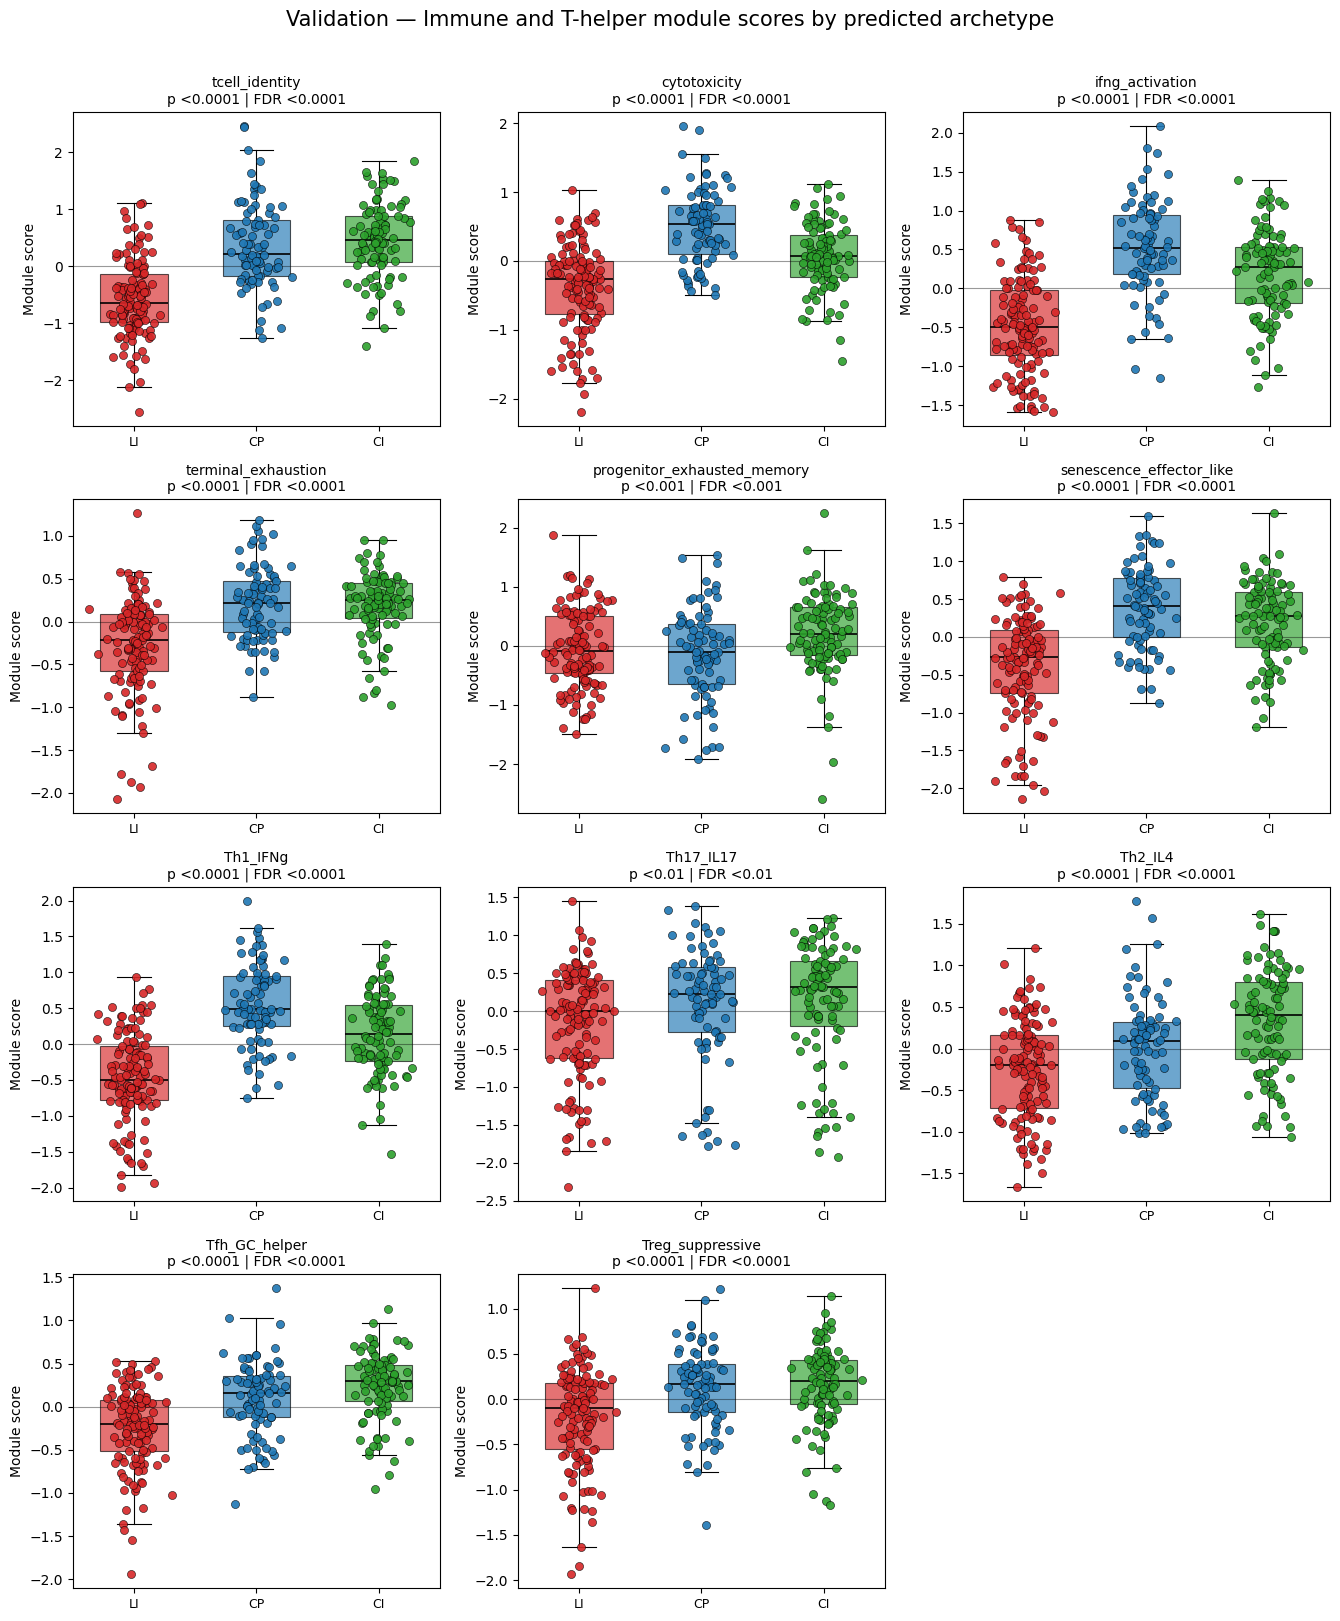

Wrote figures/supplemental_fig5/figS5C_val_immune_thelper_module_scores.svg
Saved: data/supplementary/supplemental_fig5/figS5C_val_module_scores_long.csv
Saved: data/supplementary/supplemental_fig5/figS5C_val_module_kruskal_stats.csv


In [5]:
# Fig 3E–H — immune / T-helper module scores
immune_contrasts = {
    "Th1_minus_Th2": ("Th1_IFNg", "Th2_IL4"),
    "Th17_minus_Th2": ("Th17_IL17", "Th2_IL4"),
    "Tfh_minus_Treg": ("Tfh_GC_helper", "Treg_suppressive"),
    "TerminalExhaustion_minus_Progenitor": ("terminal_exhaustion", "progenitor_exhausted_memory"),
    "Cytotoxicity_minus_Exhaustion": ("cytotoxicity", "terminal_exhaustion"),
}
plot_long_imm, wide_imm, presence_imm = vf.compute_module_scores(
    gep, archetype_label, vf.IMMUNE_THELPER_MODULES, immune_contrasts
)
display(presence_imm)
stats_imm = vf.module_kruskal_stats(plot_long_imm)
display(stats_imm.sort_values("q"))

modules_eh = [
    "tcell_identity", "cytotoxicity", "ifng_activation", "terminal_exhaustion",
    "progenitor_exhausted_memory", "senescence_effector_like",
    "Th1_IFNg", "Th17_IL17", "Th2_IL4", "Tfh_GC_helper", "Treg_suppressive",
]
vf.plot_module_scores(
    plot_long_imm, stats_imm, modules_eh,
    out_path=FIG_DIR / "figS5C_val_immune_thelper_module_scores.svg",
    suptitle="Validation — Immune and T-helper module scores by predicted archetype",
)
log_wrote(FIG_DIR / "figS5C_val_immune_thelper_module_scores.svg", REPO_ROOT)
log_saved(write_supplementary_table(plot_long_imm, REPO_ROOT, "figS5C_val_module_scores_long"), REPO_ROOT)
log_saved(write_supplementary_table(stats_imm, REPO_ROOT, "figS5C_val_module_kruskal_stats"), REPO_ROOT)

## Fig S5D — GSEA hallmark dotplot (validation)

One-vs-rest GSEA on patient-level expression ranks (MSigDB Hallmark 2020).

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/dlbcl/validation_figures.py:668: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nes_sel.stack(dropna=False).rename("NES").to_frame()
/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/dlbcl/validation_figures.py:669: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .join(fdr_sel.stack(dropna=False).rename("fdr"), how="left")


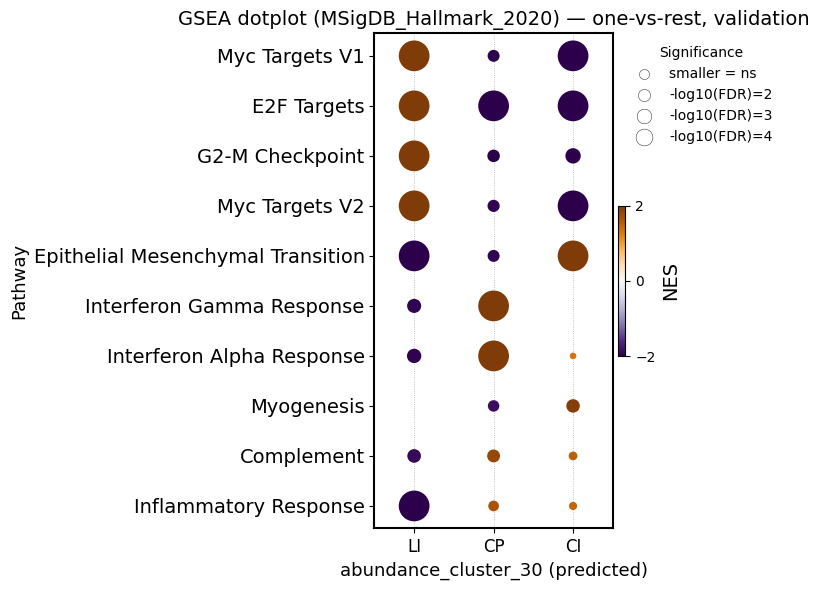

Wrote figures/supplemental_fig5/figS5D_val_gsea_dotplot.svg
Saved: data/supplementary/supplemental_fig5/figS5D_val_gsea_long.csv


In [6]:
# Fig 3O — GSEA dotplot (one-vs-rest patient-level ranking, MSigDB Hallmark)
try:
    gsea_long = vf.run_archetype_gsea(X, y, cluster_order)
    GSEA_OUT = FIG_DIR / "gsea_tumorimmune_archetype_patientlevel"
    GSEA_OUT.mkdir(parents=True, exist_ok=True)
    gsea_long.to_csv(GSEA_OUT / "gsea_one_vs_rest_long.csv", index=False)
    nes_sel, fdr_sel = vf.plot_gsea_dotplot(
        gsea_long, cluster_order, out_path=FIG_DIR / "figS5D_val_gsea_dotplot.svg"
    )
    nes_sel.to_csv(GSEA_OUT / "selected_pathway_NES_matrix.csv")
    fdr_sel.to_csv(GSEA_OUT / "selected_pathway_FDR_matrix.csv")
    log_wrote(FIG_DIR / "figS5D_val_gsea_dotplot.svg", REPO_ROOT)
    log_saved(write_supplementary_table(gsea_long, REPO_ROOT, "figS5D_val_gsea_long"), REPO_ROOT)
except Exception as exc:
    print(f"Fig 3O GSEA skipped: {type(exc).__name__}: {exc}")
    print("Requires gseapy + network access to download MSigDB_Hallmark_2020.")